In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import random
import json
from google.colab import files
SEED = 900729
dir_path = './data'
train_path = './data/Training'
test_path = './data/Testing'
uploaded=files.upload()


Saving kaggle.json to kaggle.json


In [2]:
!ls
with open("kaggle.json") as f:
    kaggle_creds = json.load(f)

username = kaggle_creds["username"]
key = kaggle_creds["key"]

os.environ['KAGGLE_USERNAME'] = username
os.environ['KAGGLE_KEY'] = key

kaggle.json  sample_data


In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()



api.dataset_download_files("masoudnickparvar/brain-tumor-mri-dataset", path="./data", unzip=True)




Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


In [4]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [5]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [6]:
tr_orginal_df = train_df(train_path)
ts_orginal_df = test_df(test_path)
ts_orginal_df

,Class Path,Class
0,./data/Testing/notumor/Te-no_0154.jpg,notumor
1,./data/Testing/notumor/Te-no_0187.jpg,notumor
2,./data/Testing/notumor/Te-no_0047.jpg,notumor
3,./data/Testing/notumor/Te-no_0341.jpg,notumor
4,./data/Testing/notumor/Te-noTr_0005.jpg,notumor
...,...,...
1306,./data/Testing/glioma/Te-gl_0136.jpg,glioma
1307,./data/Testing/glioma/Te-gl_0101.jpg,glioma
1308,./data/Testing/glioma/Te-gl_0175.jpg,glioma
1309,./data/Testing/glioma/Te-gl_0110.jpg,glioma


In [7]:
tr_orginal_df

,Class Path,Class
0,./data/Training/notumor/Tr-no_1288.jpg,notumor
1,./data/Training/notumor/Tr-no_0191.jpg,notumor
2,./data/Training/notumor/Tr-no_1348.jpg,notumor
3,./data/Training/notumor/Tr-no_0210.jpg,notumor
4,./data/Training/notumor/Tr-no_0611.jpg,notumor
...,...,...
5707,./data/Training/glioma/Tr-gl_1287.jpg,glioma
5708,./data/Training/glioma/Tr-gl_0139.jpg,glioma
5709,./data/Training/glioma/Tr-gl_0639.jpg,glioma
5710,./data/Training/glioma/Tr-gl_0257.jpg,glioma


In [8]:
val_df, tr_df = train_test_split(tr_orginal_df, train_size=0.25, random_state=SEED, stratify=tr_orginal_df['Class'])

validation_path = './data/Validation'
Path(validation_path).mkdir(exist_ok=True)

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
for class_name in classes:
    class_validation_path = Path(validation_path) / class_name
    class_validation_path.mkdir(exist_ok=True)

errors = []

for idx, row in val_df.iterrows():
    try:
        source_path = Path(row['Class Path'])

        filename = source_path.name
        class_name = row['Class']
        destination_path = Path(validation_path) / class_name / filename

        shutil.move(str(source_path), str(destination_path))

    except Exception as e:
        errors.append({
            'file': row['Class Path'],
            'class': row['Class'],
            'error': str(e)
        })


if errors:
    print(f"Errors: {len(errors)}")
    for error in errors:
        print(f"  - {error['class']}: {Path(error['file']).name} - {error['error']}")

val_df_updated = val_df.copy()
val_df_updated['Class Path'] = val_df_updated.apply(
    lambda row: str(Path(validation_path) / row['Class'] / Path(row['Class Path']).name),
    axis=1
)

tr_df_updated = train_df(train_path)

val_df = val_df_updated
tr_df = tr_df_updated

val_df

,Class Path,Class
3364,data/Validation/meningioma/Tr-me_1236.jpg,meningioma
721,data/Validation/notumor/Tr-no_0411.jpg,notumor
5526,data/Validation/glioma/Tr-gl_1169.jpg,glioma
5546,data/Validation/glioma/Tr-gl_0459.jpg,glioma
4935,data/Validation/glioma/Tr-gl_0936.jpg,glioma
...,...,...
1942,data/Validation/pituitary/Tr-pi_0024.jpg,pituitary
3899,data/Validation/meningioma/Tr-me_0457.jpg,meningioma
3138,data/Validation/meningioma/Tr-me_0294.jpg,meningioma
4272,data/Validation/meningioma/Tr-me_0233.jpg,meningioma


In [9]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


transform_tr = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
transform_ts=transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
transform_val =transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform_tr)
test_dataset  = datasets.ImageFolder(root=test_path, transform=transform_ts)
val_dataset   = datasets.ImageFolder(root=validation_path, transform=transform_val)

# Reduced batch size to mitigate OutOfMemoryError
batch_size = 16 # Reduced from 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(train_dataset.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class UpSampleConcat(nn.Module):
    def __init__(self, scale_factor=2):
        super().__init__()
        self.scale_factor = scale_factor

    def forward(self, x1, x2):
        # Upsample x1 to x2 size and concatenate
        x1_up = F.interpolate(x1, size=x2.shape[2:], mode='bilinear', align_corners=True)
        return torch.cat([x1_up, x2], dim=1)

class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels=3, out_channels=4, base_filters=16):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.base_filters = base_filters

        # Encoder path (x0_0, x1_0, x2_0, x3_0, x4_0)
        self.conv0_0 = ConvBlock(in_channels, base_filters)
        self.conv1_0 = ConvBlock(base_filters, base_filters * 2)
        self.conv2_0 = ConvBlock(base_filters * 2, base_filters * 4)
        self.conv3_0 = ConvBlock(base_filters * 4, base_filters * 8)
        self.conv4_0 = ConvBlock(base_filters * 8, base_filters * 16)

        self.pool = nn.MaxPool2d(2, 2)

        # Decoder path with nested skip connections
        # Corrected input channels for convolutional blocks in the decoder
        self.up1_0_1 = UpSampleConcat()
        self.conv0_1 = ConvBlock(base_filters + base_filters * 2, base_filters)

        self.up2_0_1 = UpSampleConcat()
        self.conv1_1 = ConvBlock(base_filters * 2 + base_filters * 4, base_filters * 2)

        self.up3_0_1 = UpSampleConcat()
        self.conv2_1 = ConvBlock(base_filters * 4 + base_filters * 8, base_filters * 4)

        self.up4_0_1 = UpSampleConcat()
        self.conv3_1 = ConvBlock(base_filters * 8 + base_filters * 16, base_filters * 8)

        self.up1_1_2 = UpSampleConcat()
        self.conv0_2 = ConvBlock(base_filters + base_filters + base_filters * 2, base_filters) # x0_0, x0_1, upsampled x1_1

        self.up2_1_2 = UpSampleConcat()
        self.conv1_2 = ConvBlock(base_filters * 2 + base_filters * 2 + base_filters * 4, base_filters * 2) # x1_0, x1_1, upsampled x2_1

        self.up3_1_2 = UpSampleConcat()
        self.conv2_2 = ConvBlock(base_filters * 4 + base_filters * 4 + base_filters * 8, base_filters * 4) # x2_0, x2_1, upsampled x3_1

        self.up1_2_3 = UpSampleConcat()
        self.conv0_3 = ConvBlock(base_filters + base_filters + base_filters + base_filters * 2, base_filters) # x0_0, x0_1, x0_2, upsampled x1_2

        self.up2_2_3 = UpSampleConcat()
        self.conv1_3 = ConvBlock(base_filters * 2 + base_filters * 2 + base_filters * 2 + base_filters * 4, base_filters * 2) # x1_0, x1_1, x1_2, upsampled x2_2

        self.up1_3_4 = UpSampleConcat()
        self.conv0_4 = ConvBlock(base_filters + base_filters + base_filters + base_filters + base_filters * 2, base_filters) # x0_0, x0_1, x0_2, x0_3, upsampled x1_3


        self.final = nn.Conv2d(base_filters, out_channels, kernel_size=1)

    def forward(self, x):
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))

        x3_1 = self.conv3_1(self.up4_0_1(x4_0, x3_0))
        x2_1 = self.conv2_1(self.up3_0_1(x3_1, x2_0))
        x1_1 = self.conv1_1(self.up2_0_1(x2_1, x1_0))
        x0_1 = self.conv0_1(self.up1_0_1(x1_1, x0_0))

        x2_2 = self.conv2_2(self.up3_1_2(x3_1, torch.cat([x2_0, x2_1], dim=1))) # Concatenate x2_0 and x2_1 for skip connection
        x1_2 = self.conv1_2(self.up2_1_2(x2_2, torch.cat([x1_0, x1_1], dim=1))) # Concatenate x1_0 and x1_1 for skip connection
        x0_2 = self.conv0_2(self.up1_1_2(x1_2, torch.cat([x0_0, x0_1], dim=1))) # Concatenate x0_0 and x0_1 for skip connection

        x1_3 = self.conv1_3(self.up2_2_3(x2_2, torch.cat([x1_0, x1_1, x1_2], dim=1))) # Concatenate x1_0, x1_1, x1_2 for skip connection
        x0_3 = self.conv0_3(self.up1_2_3(x1_3, torch.cat([x0_0, x0_1, x0_2], dim=1))) # Concatenate x0_0, x0_1, x0_2 for skip connection

        x0_4 = self.conv0_4(self.up1_3_4(x1_3, torch.cat([x0_0, x0_1, x0_2, x0_3], dim=1))) # Concatenate x0_0, x0_1, x0_2, x0_3 for skip connection


        out = self.final(x0_4)
        return out

In [11]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0 # Reset patience
        else:
            self.counter += 1 # Increase if no improvement
        return self.counter >= self.patience # True = stop

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class UNetPlusPlusForClassification(nn.Module):
    def __init__(self, unetpp_model, num_classes):
        super().__init__()
        self.unetpp = unetpp_model
        # Modify the final layer for classification
        # We'll remove the original final convolutional layer and add a new classification head
        self.classification_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), # Global Average Pooling
            nn.Flatten(),
            nn.Linear(self.unetpp.base_filters, num_classes) # Linear layer for classification
        )

    def forward(self, x):
        # Pass through the UNet++ encoder and decoder up to the last feature map before the original final layer
        x0_0 = self.unetpp.conv0_0(x)
        x1_0 = self.unetpp.conv1_0(self.unetpp.pool(x0_0))
        x2_0 = self.unetpp.conv2_0(self.unetpp.pool(x1_0))
        x3_0 = self.unetpp.conv3_0(self.unetpp.pool(x2_0))
        x4_0 = self.unetpp.conv4_0(self.unetpp.pool(x3_0))

        x3_1 = self.unetpp.conv3_1(self.unetpp.up4_0_1(x4_0, x3_0))
        x2_1 = self.unetpp.conv2_1(self.unetpp.up3_0_1(x3_1, x2_0))
        x1_1 = self.unetpp.conv1_1(self.unetpp.up2_0_1(x2_1, x1_0))
        x0_1 = self.unetpp.conv0_1(self.unetpp.up1_0_1(x1_1, x0_0))

        x2_2 = self.unetpp.conv2_2(self.unetpp.up3_1_2(x3_1, torch.cat([x2_0, x2_1], dim=1)))
        x1_2 = self.unetpp.conv1_2(self.unetpp.up2_1_2(x2_2, torch.cat([x1_0, x1_1], dim=1)))
        x0_2 = self.unetpp.conv0_2(self.unetpp.up1_1_2(x1_2, torch.cat([x0_0, x0_1], dim=1)))

        x1_3 = self.unetpp.conv1_3(self.unetpp.up2_2_3(x2_2, torch.cat([x1_0, x1_1, x1_2], dim=1)))
        x0_3 = self.unetpp.conv0_3(self.unetpp.up1_2_3(x1_3, torch.cat([x0_0, x0_1, x0_2], dim=1)))

        x0_4 = self.unetpp.conv0_4(self.unetpp.up1_3_4(x1_3, torch.cat([x0_0, x0_1, x0_2, x0_3], dim=1)))

        # Pass the final feature map through the classification head
        out = self.classification_head(x0_4)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the original UNetPlusPlus model (without the final segmentation layer)
# and then wrap it with the classification head
unetpp_base = UNetPlusPlus(in_channels=3, out_channels=4, base_filters=32) # out_channels here doesn't matter as we replace the final layer
model = UNetPlusPlusForClassification(unetpp_base, num_classes=len(train_dataset.classes))
model.to(device)

print(f"Using device: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
early_stopping = EarlyStopping(patience=5, min_delta=0.001)
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images) # Outputs shape: [batch, num_classes]

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()


    epoch_loss = running_loss / len(train_loader.dataset)
    train_accuracy = 100 * correct_train / total_train
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {epoch_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = 100 * correct_val / total_val
    print(f"Epoch [{epoch+1}/{epochs}], Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")
    if early_stopping(val_loss):
        print("Early stopping triggered!")
        break

print("Training finished.")

Using device: cuda


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'model.pth')
files.download('model.pth')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
from google.colab import files
uploaded = files.upload()
model.load_state_dict(torch.load('model.pth'))

Saving model.pth to model.pth


<All keys matched successfully>

Test Loss: 0.2556, Test Accuracy: 91.00%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.87      0.92       300
  meningioma       0.94      0.85      0.89       306
     notumor       0.99      0.92      0.95       405
   pituitary       0.78      1.00      0.87       300

    accuracy                           0.91      1311
   macro avg       0.92      0.91      0.91      1311
weighted avg       0.92      0.91      0.91      1311


Confusion Matrix:
[[262   6   0  32]
 [  3 260   5  38]
 [  7  10 372  16]
 [  0   1   0 299]]


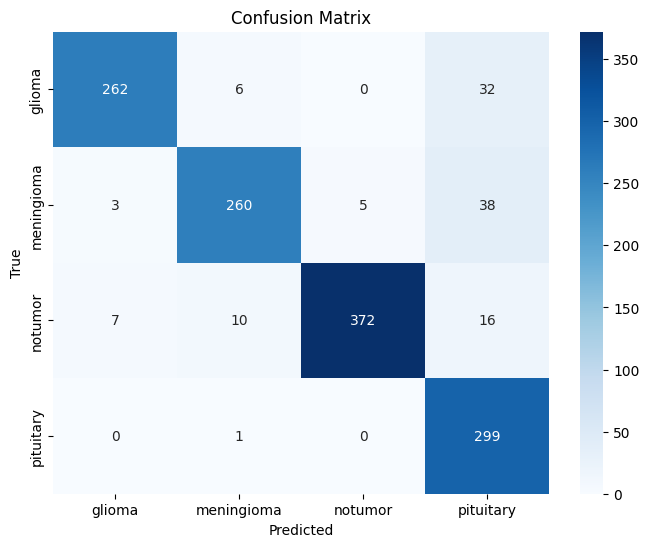

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()  # Set the model to evaluation mode
test_loss = 0.0
correct_test = 0
total_test = 0
all_labels = []
all_predicted = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())

avg_test_loss = test_loss / len(test_loader.dataset)
test_accuracy = 100 * correct_test / total_test

print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

# Display Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_predicted, target_names=train_dataset.classes))

# Display Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_predicted)
print(cm)

# Optional: Visualize Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


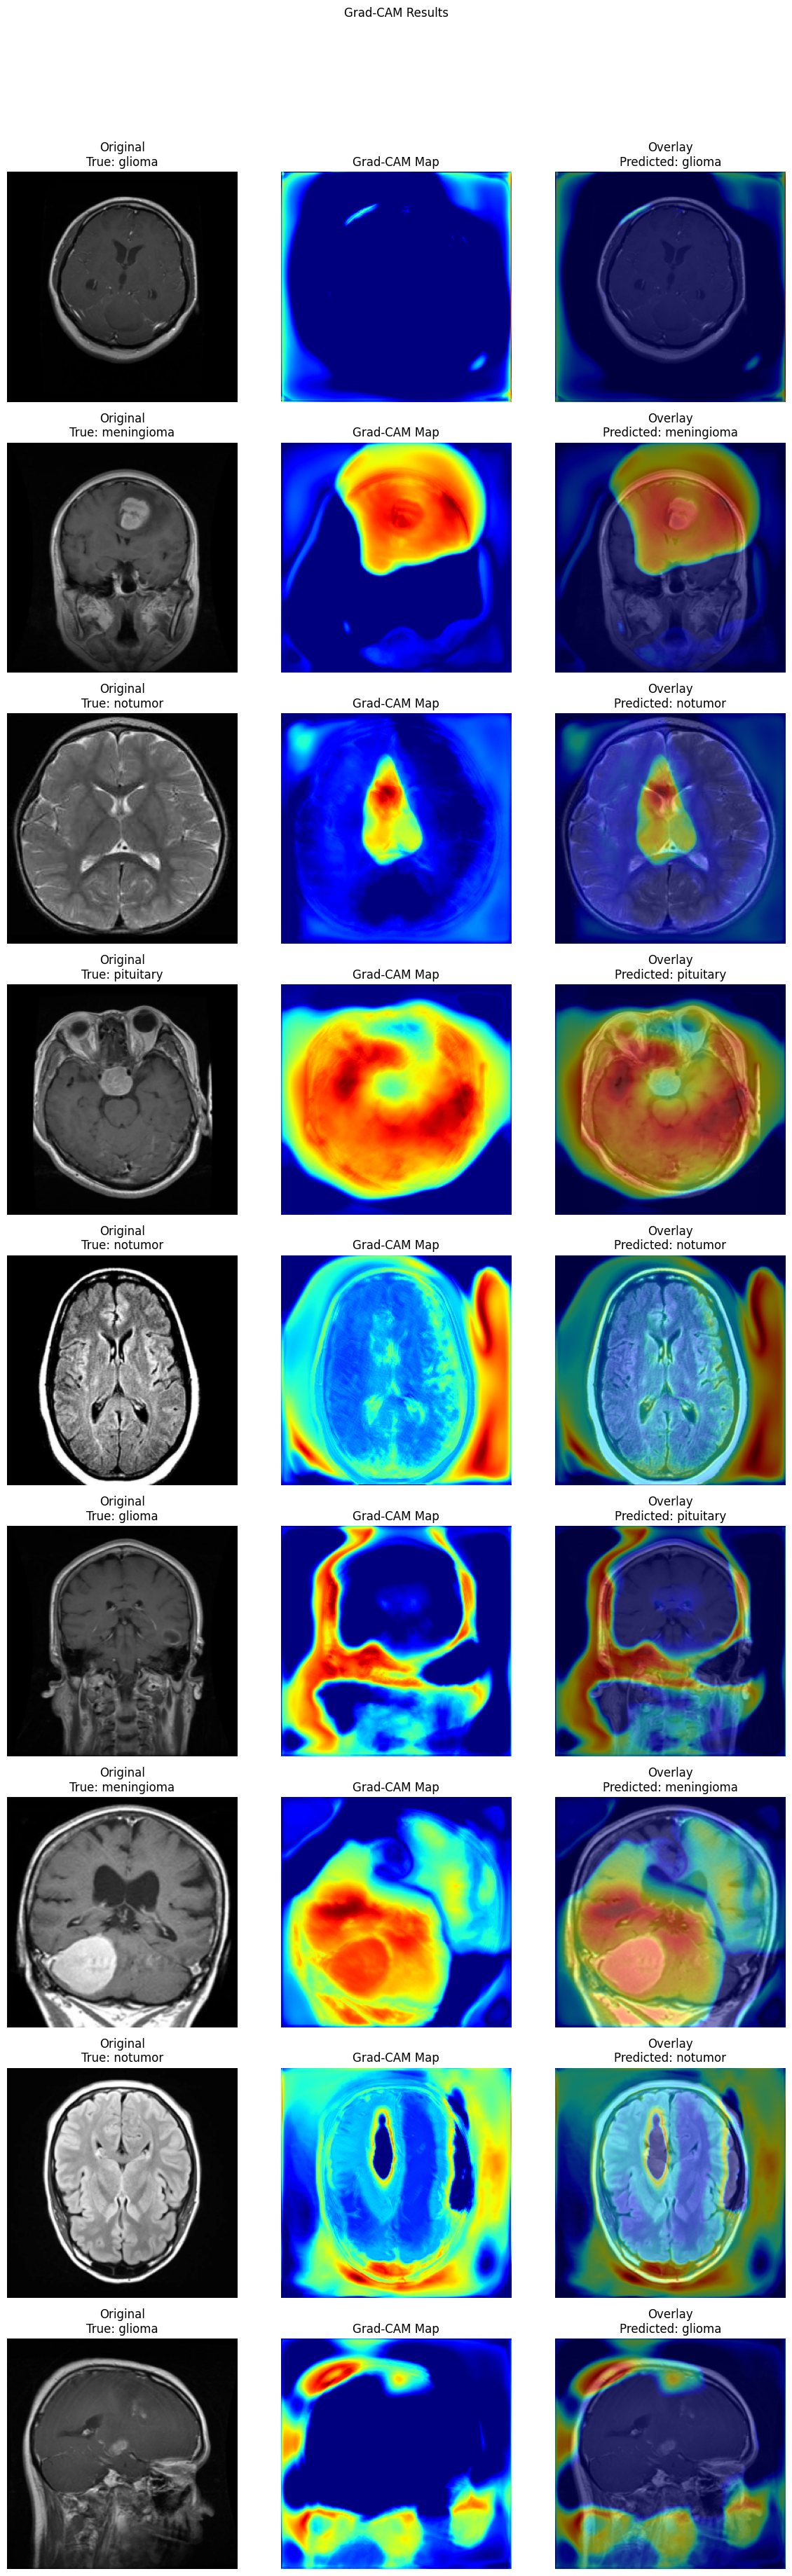

In [30]:
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Zakładam, że masz model UNet++ zdefiniowany i załadowany jako 'model'
# oraz masz dane wejściowe 'input_tensor' (np. obraz do segmentacji)

def generate_grad_cam(model, input_tensor, target_layer, target_category):
    """
    Generates a Grad-CAM heatmap for a given model, input tensor, target layer, and target category.

    Args:
        model (torch.nn.Module): The trained model.
        input_tensor (torch.Tensor): The input image tensor.
        target_layer (torch.nn.Module): The layer to extract activations and gradients from.
        target_category (int): The index of the target class for Grad-CAM.

    Returns:
        torch.Tensor: The generated Grad-CAM heatmap, resized to the input image size.
    """
    activations = None
    gradients = None

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output.detach()

    def backward_hook(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0].detach()

    # Register hooks on the target layer
    hook_handles = []
    hook_handles.append(target_layer.register_forward_hook(forward_hook))
    hook_handles.append(target_layer.register_backward_hook(backward_hook))

    # Ensure input tensor requires gradients
    input_tensor.requires_grad_(True)

    # Perform forward pass
    output = model(input_tensor)

    # Zero gradients and perform backward pass for the target category
    model.zero_grad()
    if target_category is not None:
        output[0, target_category].backward()
    else:
        # If target_category is None, backpropagate the maximum predicted class score
        _, target_category = torch.max(output, dim=1)
        output[0, target_category].backward()


    # Calculate Grad-CAM map
    weights = torch.mean(gradients, dim=[2, 3], keepdim=True)  # Global average pooling of gradients
    grad_cam_map = F.relu(torch.sum(weights * activations, dim=1, keepdim=True))  # Weighted sum of activations + ReLU

    # Normalization to range 0-1
    grad_cam_map -= grad_cam_map.min()
    grad_cam_map /= grad_cam_map.max()

    # Resize Grad-CAM map to the size of the input image
    heatmap_resized = TF.resize(grad_cam_map, input_tensor.shape[2:])

    # Remove the hooks
    for handle in hook_handles:
        handle.remove()

    return heatmap_resized, output

# Set the model to evaluation mode
model.eval()

# Define the target layer for Grad-CAM (e.g., the last convolutional layer before the classification head)
# Based on the UNetPlusPlusForClassification model, conv0_4 is a good candidate
target_layer = model.unetpp.conv0_4.relu # Target the ReLU activation after the last conv block

# Select 9 random samples from the test dataset
num_samples = 9
sample_indices = random.sample(range(len(test_dataset)), num_samples)

# Create a figure to display the results
fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
fig.suptitle("Grad-CAM Results", y=1.02)

for i, sample_idx in enumerate(sample_indices):
    img, label = test_dataset[sample_idx]
    input_tensor = img.unsqueeze(0).to(device)

    # Generate Grad-CAM for the true class
    heatmap_resized, output = generate_grad_cam(model, input_tensor, target_layer, label)

    # Get predicted and true class
    _, predicted_label = torch.max(output.data, 1)
    predicted_class = train_dataset.classes[predicted_label.item()]
    true_class = train_dataset.classes[label]

    heatmap_np = heatmap_resized.cpu().numpy()[0][0]
    img_np = input_tensor.cpu().detach().numpy()[0, 0]
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # Display original image
    axes[i, 0].imshow(img_np, cmap='gray')
    axes[i, 0].set_title(f"Original\nTrue: {true_class}")
    axes[i, 0].axis('off')

    # Display Grad-CAM map
    axes[i, 1].imshow(heatmap_np, cmap='jet')
    axes[i, 1].set_title("Grad-CAM Map")
    axes[i, 1].axis('off')

    # Display overlay
    axes[i, 2].imshow(img_np, cmap='gray')
    axes[i, 2].imshow(heatmap_np, cmap='jet', alpha=0.5)
    axes[i, 2].set_title(f"Overlay\nPredicted: {predicted_class}")
    axes[i, 2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()